In [6]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, accuracy_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
#  Generate Customer Churn Dataset
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'age': np.random.randint(18, 70, n),
    'tenure_months': np.random.randint(1, 72, n),
    'monthly_charges': np.random.uniform(20, 120, n),
    'num_products': np.random.randint(1, 5, n),
    'has_internet': np.random.randint(0, 2, n),
    'has_phone': np.random.randint(0, 2, n),
    'num_complaints': np.random.randint(0, 10, n),
    'satisfaction_score': np.random.randint(1, 6, n),
})

# Create realistic churn based on features
churn_prob = (
    0.3 * (df['num_complaints'] > 3).astype(int) +
    0.25 * (df['satisfaction_score'] < 3).astype(int) +
    0.2 * (df['tenure_months'] < 12).astype(int) +
    0.15 * (df['monthly_charges'] > 90).astype(int) +
    np.random.uniform(0, 0.1, n)
)
df['churn'] = (churn_prob > 0.3).astype(int)

print("Shape:", df.shape)
print("\nChurn Distribution:")
print(df['churn'].value_counts())
print(f"\nChurn Rate: {df['churn'].mean():.2%}")
df.head()

Shape: (1000, 9)

Churn Distribution:
churn
1    732
0    268
Name: count, dtype: int64

Churn Rate: 73.20%


,age,tenure_months,monthly_charges,num_products,has_internet,has_phone,num_complaints,satisfaction_score,churn
0,56,15,55.162269,2,0,1,8,2,1
1,69,64,30.142083,1,1,1,3,5,0
2,46,28,68.587176,4,0,1,8,1,1
3,32,39,45.677657,4,0,1,3,5,0
4,60,57,48.487290,2,1,1,1,4,0


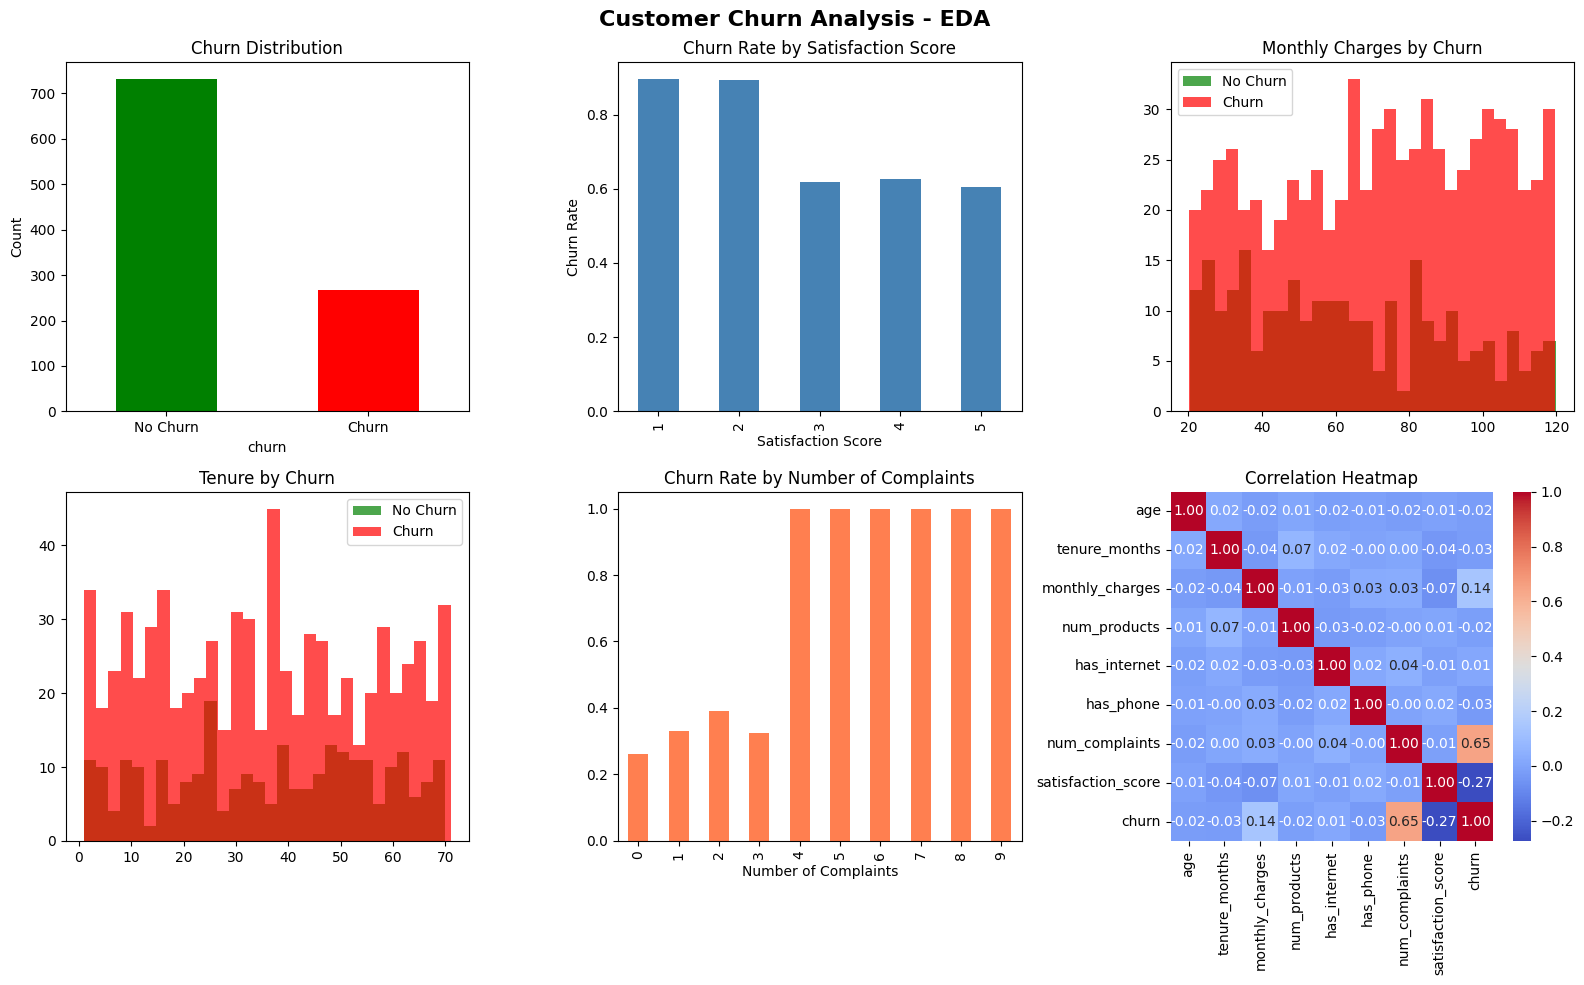

EDA visualization saved!


In [8]:
#  EDA Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Customer Churn Analysis - EDA', fontsize=16, fontweight='bold')

# Plot 1 - Churn Distribution
df['churn'].value_counts().plot(kind='bar', ax=axes[0,0], color=['green', 'red'])
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xticklabels(['No Churn', 'Churn'], rotation=0)
axes[0,0].set_ylabel('Count')

# Plot 2 - Churn by Satisfaction Score
df.groupby('satisfaction_score')['churn'].mean().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Churn Rate by Satisfaction Score')
axes[0,1].set_xlabel('Satisfaction Score')
axes[0,1].set_ylabel('Churn Rate')

# Plot 3 - Monthly Charges Distribution
axes[0,2].hist(df[df['churn']==0]['monthly_charges'], bins=30, alpha=0.7, label='No Churn', color='green')
axes[0,2].hist(df[df['churn']==1]['monthly_charges'], bins=30, alpha=0.7, label='Churn', color='red')
axes[0,2].set_title('Monthly Charges by Churn')
axes[0,2].legend()

# Plot 4 - Tenure vs Churn
axes[1,0].hist(df[df['churn']==0]['tenure_months'], bins=30, alpha=0.7, label='No Churn', color='green')
axes[1,0].hist(df[df['churn']==1]['tenure_months'], bins=30, alpha=0.7, label='Churn', color='red')
axes[1,0].set_title('Tenure by Churn')
axes[1,0].legend()

# Plot 5 - Complaints vs Churn
df.groupby('num_complaints')['churn'].mean().plot(kind='bar', ax=axes[1,1], color='coral')
axes[1,1].set_title('Churn Rate by Number of Complaints')
axes[1,1].set_xlabel('Number of Complaints')

# Plot 6 - Correlation Heatmap
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('churn_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA visualization saved!")

In [9]:
#  Model Training & Evaluation
X = df.drop('churn', axis=1)
y = df['churn']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]):.4f}")
print(classification_report(y_test, lr_pred))

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}")
print(classification_report(y_test, rf_pred))

=== Logistic Regression ===
Accuracy: 0.9200
ROC AUC: 0.9569
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        43
           1       0.97      0.93      0.95       157

    accuracy                           0.92       200
   macro avg       0.87      0.91      0.89       200
weighted avg       0.93      0.92      0.92       200

=== Random Forest ===
Accuracy: 0.9800
ROC AUC: 0.9966
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.99      0.99      0.99       157

    accuracy                           0.98       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.98      0.98      0.98       200



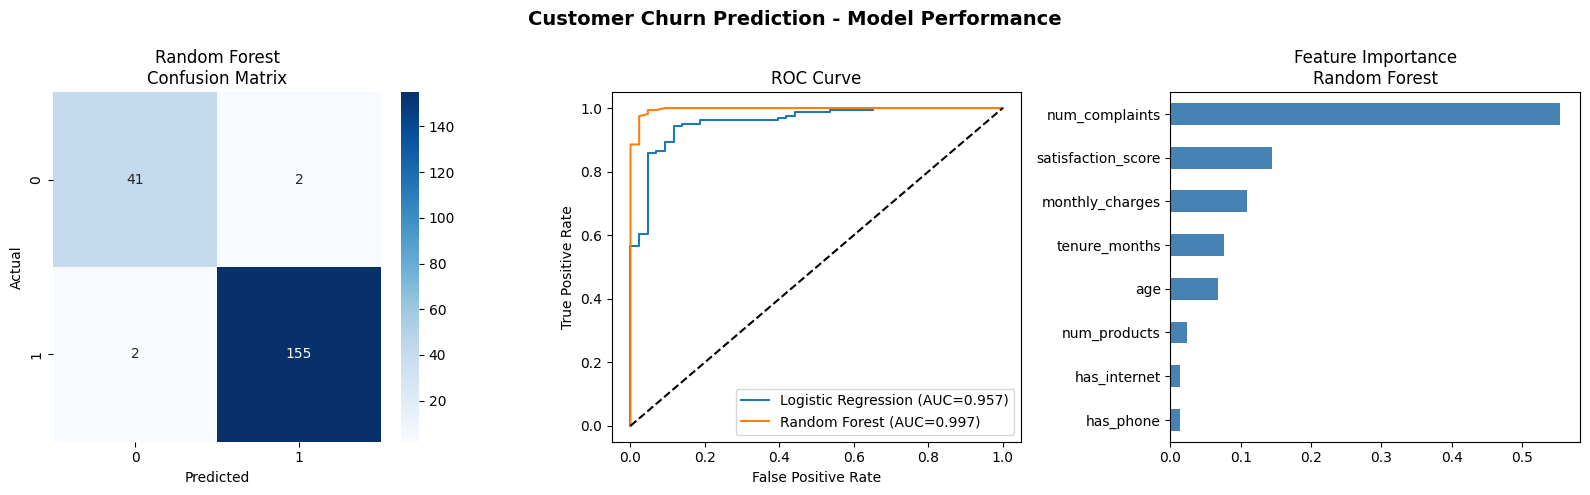

Done!


In [10]:
#  Model Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Customer Churn Prediction - Model Performance', fontsize=14, fontweight='bold')

# Plot 1 - Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 - ROC Curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:,1])
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
axes[1].plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]):.3f})')
axes[1].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f})')
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Plot 3 - Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Feature Importance\nRandom Forest')

plt.tight_layout()
plt.savefig('churn_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

# Customer Churn Prediction

## Project Overview
Built a machine learning pipeline to predict customer churn using demographic and behavioral data. Helps businesses identify at-risk customers and take proactive retention actions.

## Key Findings
- **Number of complaints is the strongest predictor** of churn (feature importance ~0.55)
- **Satisfaction score and monthly charges** are the next most important features
- **Random Forest achieved 98% accuracy** and AUC of 0.997
- **Logistic Regression achieved 92% accuracy** and AUC of 0.957

## Tech Stack
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

## Note
Dataset is synthetically generated to demonstrate ML classification techniques on business analytics data.